# 04, Random Forest

**Author:** Karan Homayounfar (25065219), UWE Bristol

Random Forest is the main model. Breiman (2001) showed that combining many decorrelated decision trees via bagging and random feature subsampling reduces variance without increasing bias, overcoming the core weakness of standalone decision trees.  
Compared to Logistic Regression, Random Forest handles non-linear feature interactions without requiring explicit feature crosses.

**Decision Tree rejection argument:** A single decision tree is high-variance: small changes in training data can produce drastically different trees (Breiman et al., 1984). Random Forest remedies this through ensemble averaging, making it strictly preferable as the main model.

In [4]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, confusion_matrix,
    roc_curve, average_precision_score, precision_recall_curve
)
from sklearn.inspection import permutation_importance

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

DATA_DIR    = '../data/processed'
FIGURES_DIR = '../report/figures'
import os
os.makedirs(FIGURES_DIR, exist_ok=True)

In [5]:
X_train = np.load(f'{DATA_DIR}/X_train.npy')
X_test  = np.load(f'{DATA_DIR}/X_test.npy')
y_train = np.load(f'{DATA_DIR}/y_train.npy')
y_test  = np.load(f'{DATA_DIR}/y_test.npy')

with open(f'{DATA_DIR}/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

print(f'X_train: {X_train.shape},  X_test: {X_test.shape}')

X_train: (200000, 51),  X_test: (50000, 51)


## 1. Nested cross-validation

In [6]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'n_estimators': [200],
    'max_features': ['sqrt', 0.3],
    'min_samples_leaf': [1, 5],
}

base_rf = RandomForestClassifier(
    class_weight='balanced',
    oob_score=False,
    n_jobs=1,          # GridSearchCV below already parallelises; nesting n_jobs=-1
    random_state=42     # inside n_jobs=-1 is what caused the joblib PicklingError on Windows
)

rf_inner = GridSearchCV(
    base_rf,
    param_grid,
    cv=inner_cv,
    scoring='f1_macro',
    n_jobs=1   # was -1; multiprocessing kept crashing joblib's pickler on Windows
)

outer_f1  = []
outer_auc = []
best_params_list = []

print('Running nested CV (5 outer x 3 inner)...')
for fold, (train_idx, val_idx) in enumerate(outer_cv.split(X_train, y_train), 1):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    rf_inner.fit(X_tr, y_tr)
    best_params_list.append(rf_inner.best_params_)

    y_pred = rf_inner.predict(X_val)
    y_prob = rf_inner.predict_proba(X_val)[:, 1]

    f1  = f1_score(y_val, y_pred, average='macro')
    auc = roc_auc_score(y_val, y_prob)
    outer_f1.append(f1)
    outer_auc.append(auc)
    print(f'  Fold {fold}: F1-macro={f1:.4f}, ROC-AUC={auc:.4f} | best: {rf_inner.best_params_}')

print(f'\nNested CV F1-macro:  {np.mean(outer_f1):.4f} +/- {np.std(outer_f1):.4f}')
print(f'Nested CV ROC-AUC:  {np.mean(outer_auc):.4f} +/- {np.std(outer_auc):.4f}')

Running nested CV (5 outer x 3 inner)...
  Fold 1: F1-macro=0.9182, ROC-AUC=0.9861 | best: {'max_features': 0.3, 'min_samples_leaf': 1, 'n_estimators': 200}
  Fold 2: F1-macro=0.9173, ROC-AUC=0.9856 | best: {'max_features': 0.3, 'min_samples_leaf': 1, 'n_estimators': 200}
  Fold 3: F1-macro=0.9169, ROC-AUC=0.9852 | best: {'max_features': 0.3, 'min_samples_leaf': 1, 'n_estimators': 200}
  Fold 4: F1-macro=0.9175, ROC-AUC=0.9857 | best: {'max_features': 0.3, 'min_samples_leaf': 1, 'n_estimators': 200}
  Fold 5: F1-macro=0.9177, ROC-AUC=0.9861 | best: {'max_features': 0.3, 'min_samples_leaf': 1, 'n_estimators': 200}

Nested CV F1-macro:  0.9175 +/- 0.0004
Nested CV ROC-AUC:  0.9858 +/- 0.0003


## 2. Final model on full training data

In [7]:
# Most frequently selected params across outer folds
from collections import Counter

def most_common_val(lst, key):
    return Counter([p[key] for p in lst]).most_common(1)[0][0]

best_max_features   = most_common_val(best_params_list, 'max_features')
best_min_samples    = most_common_val(best_params_list, 'min_samples_leaf')

print(f'Final hyperparameters: max_features={best_max_features}, min_samples_leaf={best_min_samples}')

rf_final = RandomForestClassifier(
    n_estimators=300,
    max_features=best_max_features,
    min_samples_leaf=best_min_samples,
    class_weight='balanced',
    oob_score=True,
    n_jobs=1,   # was -1; same joblib/Windows pickling issue as above
    random_state=42
)
rf_final.fit(X_train, y_train)

print(f'OOB score: {rf_final.oob_score_:.4f}')

y_pred_test = rf_final.predict(X_test)
y_prob_test = rf_final.predict_proba(X_test)[:, 1]

rf_test_f1  = f1_score(y_test, y_pred_test, average='macro')
rf_test_auc = roc_auc_score(y_test, y_prob_test)
rf_test_pr  = average_precision_score(y_test, y_prob_test)

print(f'\nTest F1-macro:  {rf_test_f1:.4f}')
print(f'Test ROC-AUC:   {rf_test_auc:.4f}')
print(f'Test PR-AUC:    {rf_test_pr:.4f}')
print()
print(classification_report(y_test, y_pred_test, target_names=['Low potential', 'High potential']))

Final hyperparameters: max_features=0.3, min_samples_leaf=1
OOB score: 0.9406

Test F1-macro:  0.8262
Test ROC-AUC:   0.9705
Test PR-AUC:    0.8051

                precision    recall  f1-score   support

 Low potential       0.98      0.93      0.95     44612
High potential       0.59      0.86      0.70      5388

      accuracy                           0.92     50000
     macro avg       0.78      0.90      0.83     50000
  weighted avg       0.94      0.92      0.93     50000



## 3. Confusion matrix

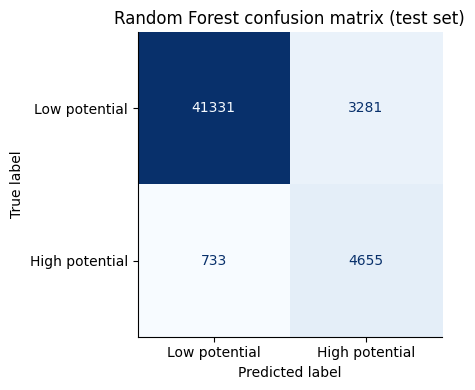

In [8]:
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Low potential', 'High potential']).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('Random Forest confusion matrix (test set)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/rf_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 4. ROC and Precision-Recall curves

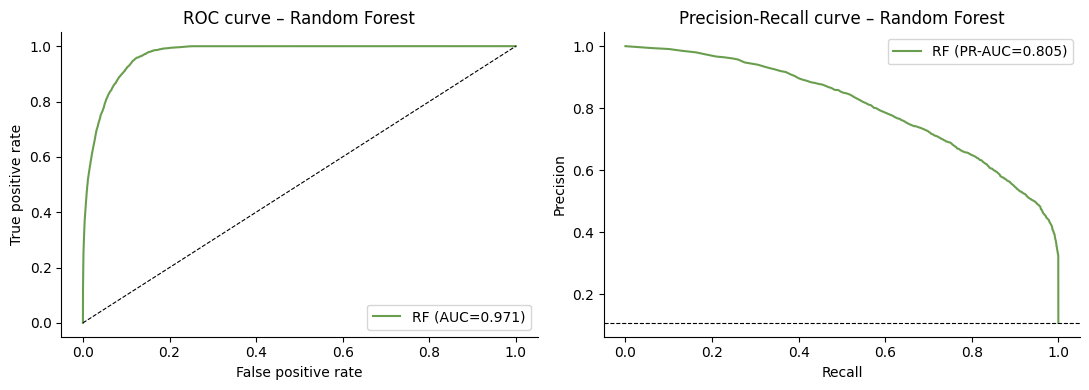

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(fpr, tpr, color='#6a9e4f', label=f'RF (AUC={rf_test_auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', linewidth=0.8)
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curve, Random Forest')
axes[0].legend()

axes[1].plot(rec, prec, color='#6a9e4f', label=f'RF (PR-AUC={rf_test_pr:.3f})')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curve, Random Forest')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/rf_roc_pr.png', bbox_inches='tight')
plt.show()

## 5. Feature importances (permutation)

Computing permutation importances on test set (may take ~1 min)...


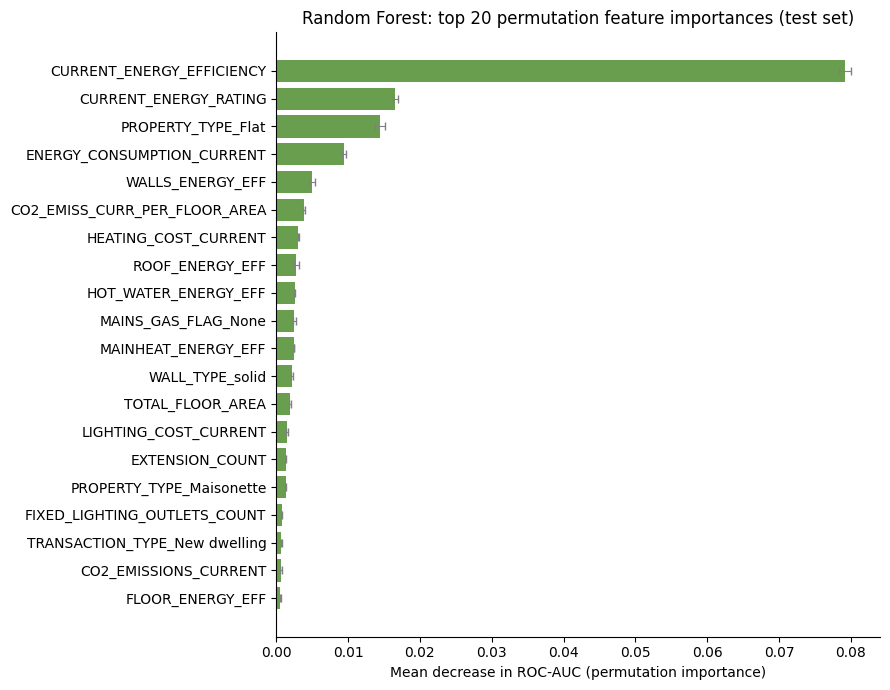

In [10]:
print('Computing permutation importances on test set (may take ~1 min)...')
perm_imp = permutation_importance(
    rf_final, X_test, y_test,
    n_repeats=10,
    scoring='roc_auc',
    random_state=42,
    n_jobs=2           # capped rather than -1: shipping the fitted forest to every
)                        # core at once is what crashes joblib's pickler on Windows

top_n = 20
sorted_idx = np.argsort(perm_imp.importances_mean)[::-1][:top_n]
top_feature_names = [feature_names[i] for i in sorted_idx]
top_means  = perm_imp.importances_mean[sorted_idx]
top_stds   = perm_imp.importances_std[sorted_idx]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_feature_names[::-1], top_means[::-1],
        xerr=top_stds[::-1], color='#6a9e4f', ecolor='gray',
        capsize=3, error_kw={'linewidth': 0.8})
ax.set_xlabel('Mean decrease in ROC-AUC (permutation importance)')
ax.set_title('Random Forest: top 20 permutation feature importances (test set)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/rf_permutation_importances.png', bbox_inches='tight')
plt.show()

## 6. Save predictions and metrics

In [11]:
np.save(f'{DATA_DIR}/rf_test_probs.npy', y_prob_test)
np.save(f'{DATA_DIR}/rf_test_preds.npy', y_pred_test)

with open(f'{DATA_DIR}/rf_final_model.pkl', 'wb') as f:
    pickle.dump(rf_final, f)

rf_metrics = {
    'model': 'Random Forest',
    'best_max_features': best_max_features,
    'best_min_samples_leaf': best_min_samples,
    'oob_score': rf_final.oob_score_,
    'cv_f1_macro_mean': np.mean(outer_f1),
    'cv_f1_macro_std':  np.std(outer_f1),
    'cv_roc_auc_mean':  np.mean(outer_auc),
    'cv_roc_auc_std':   np.std(outer_auc),
    'test_f1_macro': rf_test_f1,
    'test_roc_auc':  rf_test_auc,
    'test_pr_auc':   rf_test_pr,
}

with open(f'{DATA_DIR}/rf_metrics.pkl', 'wb') as f:
    pickle.dump(rf_metrics, f)

print('Saved RF predictions and metrics.')
print('\n=== RF SUMMARY ===')
for k, v in rf_metrics.items():
    print(f'  {k}: {v}')

Saved RF predictions and metrics.

=== RF SUMMARY ===
  model: Random Forest
  best_max_features: 0.3
  best_min_samples_leaf: 1
  oob_score: 0.94065
  cv_f1_macro_mean: 0.9175142931034305
  cv_f1_macro_std: 0.0004405429281447933
  cv_roc_auc_mean: 0.9857655074809835
  cv_roc_auc_std: 0.0003305441026241787
  test_f1_macro: 0.8262143600201715
  test_roc_auc: 0.9705201396303864
  test_pr_auc: 0.8051306268312773
